In [1]:
from bam_utils import *

import torch
import torch.nn as nn
from torch.nn import functional as F
import itertools

from dataclasses import dataclass
from collections import defaultdict
from typing import Dict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}.")

Using cuda.


### Loading Data

In [2]:
from torch.utils.data import DataLoader
import dataset_utils as du

def valData(bam, ref, seq_type, method, spec, batch_size=256, num_workers=20):
    if method == "region":
        #spec: [chrom, start, end]
        ds = du.SignalBAMRegionDataset(
            bam_path=bam,
            ref_fasta_path=ref,
            seq_type=seq_type,
            chrom=spec[0],
            start=spec[1],
            end=spec[2],
        )
    if method == "nt":
        #spec: label_path
        ds = du.SignalBAMkmerValidationDataset(
            bam_path=bam,
            ref_fasta_path=ref,
            seq_type=seq_type, 
            labels_path_tsv=spec,
            max_lines=10000,
        )
    if method == "site":
        #spec: pos_list
        ds = du.SignalBAMRefPosValidationDataset(
            bam_path=bam,
            ref_fasta_path=ref,
            seq_type=seq_type,
            pos_list=spec,
            max_lines=10000,
        )
    loader = DataLoader(ds, batch_size=batch_size, num_workers=num_workers)
    return loader


In [3]:
#Human
cell = "20240321_directRNA_HEK293T"
ref_hs = "/home/zouy1/software/reference/GRCh38.primary_assembly.genome.fa"
bam = f"/home/zouy1/projects/RNAmod/VAE/data/RNA/{cell}/{cell}.final.bam"
label_path = f"/home/zouy1/projects/RNAmod/VAE/data/RNA/{cell}/{cell}.modkit.extract.chr20.bed"
#unmod_bam = "/mnt/isilon/wang_lab/umair/deepmod/model_features/r10_5khz_drd.v1_full_bam/HG002_WGA/HG002_WGA.final.bam"
#mod_bam = "/mnt/isilon/wang_lab/umair/deepmod/model_features/r10_5khz_drd.v1_full_bam/HG002/HG002.1_100_chunks.bam"

#DNA Oligos
mod_dna = "5mC"
ref_oligos_dna = '/home/zouy1/projects/RNAmod/VAE/data/oligos/DNA/all_5mers.fa'
unmod_bam_dna = "/home/zouy1/projects/RNAmod/VAE/data/oligos/DNA/control_rep1/control_rep1.subset.final.bam"
mod_bam_dna = f"/home/zouy1/projects/RNAmod/VAE/data/oligos/DNA/{mod_dna}_rep1/{mod_dna}_rep1.subset.final.bam"
pos_list_dna = f"/home/zouy1/projects/RNAmod/VAE/data/oligos/DNA/labels/all_5mers_{mod_dna}_sites.bed"

mod_rna = "m6A"
ref_oligos_rna = "/home/zouy1/projects/RNAmod/VAE/data/oligos/RNA/sampled_context_strands.fa"
unmod_bam_rna = "/home/zouy1/projects/RNAmod/VAE/data/oligos/RNA/control_rep1/control_rep1.subset.final.bam"
mod_bam_rna = f"/home/zouy1/projects/RNAmod/VAE/data/oligos/RNA/{mod_rna}_rep1/{mod_rna}_rep1.subset.final.bam"
pos_list_rna = f"/home/zouy1/projects/RNAmod/VAE/data/oligos/RNA/labels/sampled_context_{mod_rna}_sites.bed"

#Region
region1 = ["chr20", 58837550, 58890800]
region2 = ["chr22", 25343801, 25393801]

val_loader = valData(bam, ref_hs, "rna", method="nt", spec=label_path, num_workers=20)
#test_loader = valData(mod_bam, ref_hs, "dna", method="site", spec=pos_list_dna, num_workers=20)

### Evaluation

In [4]:
# Import model
import importlib
import models.model_v1_cnn_t as m  # change model here
importlib.reload(m)
model_name = m.META.name

model = m.VAE(
    n_features=11,
    seq_len=7,
    d_model=256, #256
    cnn_channels=128, #128
    n_heads=4,
    n_layers=3,
    latent_dim=16,
    dropout=0.1,
    use_cls_token=True,
).to(device)

run_name = "online_test2"
n_epoch = "19"
state_dict = f"state_dicts/{model_name}/{run_name}-epoch{n_epoch}.pt"
#state_dict = f"state_dicts/{model_name}/model_vae_cnn_be-3_e50-wga.pt"
pt = torch.load(state_dict, map_location=device)
model.load_state_dict(pt['model_state_dict'])
last_beta = pt['beta']
#check params
num_nonzero = sum((p.abs() > 1e-6).sum().item() for p in model.parameters())
nparam = sum([p.numel() for p in model.parameters()])
print(f"non-zero params: {100*num_nonzero/nparam}%")

/home/zouy1/miniconda3/envs/deepmod2/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


non-zero params: 99.99797219199286%


In [5]:
import pandas as pd
import os
import feature_utils as fu
import pyarrow as pa
import pyarrow.parquet as pq

def anomaly_score(model, loader, device, out_path):
    model.eval()
    os.makedirs(os.path.dirname(out_path) or ".", exist_ok=True)

    writer = None
    with torch.no_grad():
        for x, kmer, pos, y in loader:
            x = x.to(device)
            out = model(x)
            recon_score = ((out["x_hat"] - x) ** 2).mean(dim=(1, 2))  # [B]

            # tensors
            embs = out["mu"].detach().cpu().numpy()      # [B, D]
            scores = recon_score.detach().cpu().numpy()  # [B]
            labels = y.detach().cpu().numpy()            # [B] or [B, ...]
            # metadata
            kmers = [fu.decode_kmer(km) for km in kmer.detach().cpu()]
            pos_rows = []
            for i in range(x.shape[0]):
                pos_rows.append({k: (v[i] if isinstance(v, (list, tuple)) else v[i].item())
                                 for k, v in pos.items()})
            
            # build batch dataframe
            batch_df = pd.DataFrame({
                "scores": scores,
                "labels": labels,
                "kmer": kmers,
                "embeddings": list(embs)
            })
            pos_df = pd.json_normalize(pos_rows)
            batch_df = pd.concat([batch_df, pos_df], axis=1)
            
            table = pa.Table.from_pandas(batch_df, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(out_path, table.schema)
            writer.write_table(table)

        print("mu std:", out["mu"].std(dim=0).mean().item())
        print("logvar mean:", out["logvar"].mean().item())

    if writer is not None:
        writer.close()
        

#Run analysis
anomaly_score(model, val_loader, device, out_path="./validation/validation_result2-val.pq")
#anomaly_score(model, test_loader, device, out_path="./validation/validation_result2-test.pq")

mu std: 1.0670808553695679
logvar mean: -6.4392828941345215


In [6]:
import pandas as pd
val = pd.read_parquet("./validation/validation_result6-val.pq")
val['labels'] = 0
test = pd.read_parquet("./validation/validation_result6-test.pq")
test['labels'] = 1

df = pd.concat([val, test])

#Aggregation
def agg(df): 
    agg = df.groupby(["chrom", "ref_pos_0based", "strand", "labels"])["scores"].agg(["count","mean","median","std"]).reset_index()
    return agg
    
#agg.to_csv("../evaluation/dna.hg002-wt.full.region2.tsv", index=False, sep='\t')
ag = pd.concat([agg(val), agg(test)])

In [38]:
import pandas as pd
df = pd.read_parquet("./validation/validation_result2-val.pq")
df['labels_b'] = df['labels']>0.6

### Figures

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def pca_then_umap(embs, pca_dim=20, umap_neighbors=30, umap_min_dist=0.1, seed=0):
    # Standardize before PCA/UMAP is usually helpful
    X = StandardScaler().fit_transform(embs)

    pca = PCA(n_components=pca_dim, random_state=seed)
    Xp = pca.fit_transform(X)

    import umap
    reducer = umap.UMAP(
        n_neighbors=umap_neighbors,
        min_dist=umap_min_dist,
        n_components=2,
        random_state=seed,
        metric="euclidean",
    )
    Xu = reducer.fit_transform(Xp)
    return Xp, Xu, pca, reducer

import matplotlib.pyplot as plt

def plot_2d(X2, y, title):
    plt.figure()
    sc = plt.scatter(X2[:, 0], X2[:, 1], c=y, s=8, alpha=0.2)  # no explicit color choice
    plt.colorbar(sc, label="label")
    plt.title(title)
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.tight_layout()
    plt.show()

Xp, Xu, pca, reducer = pca_then_umap(df['embeddings'], pca_dim=16)

# PCA plot (first 2 PCs)
plot_2d(Xp[:, :2], df['labels'], "PCA of VAE embeddings (mu)")

# UMAP plot
plot_2d(Xu, df['labels'], "UMAP of VAE embeddings (mu)")


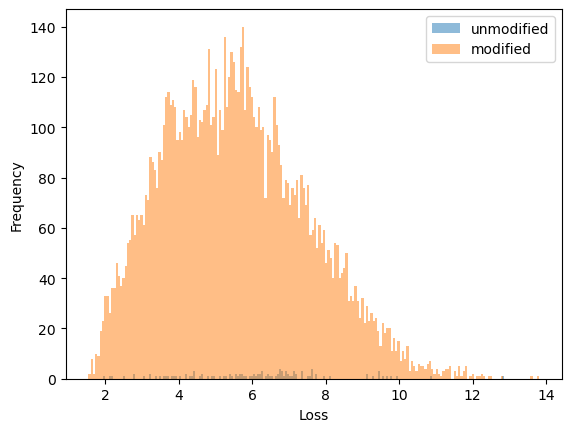

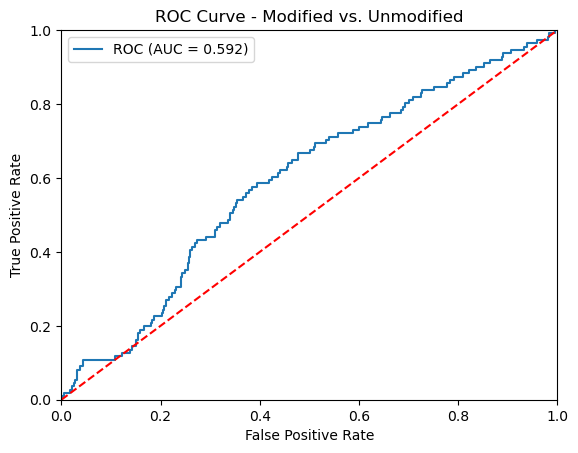

ROC AUC = 0.5918


In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from sklearn.metrics import roc_curve, precision_recall_curve, auc, average_precision_score

def plotROC(df, score_col, label_col):
    fpr, tpr, thresholds = roc_curve(df[label_col], df[score_col])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
    plt.plot([0,1],[0,1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Modified vs. Unmodified")
    plt.legend()
    plt.savefig('figures/ROC_latest.png', dpi=300)
    plt.show()
    print(f"ROC AUC = {roc_auc:.4f}")
    
def plotHist(df, score_col, label_col):
    plt.hist(df.loc[df[label_col]==1,score_col], bins=200, alpha=0.5, label='unmodified');
    plt.hist(df.loc[df[label_col]==0,score_col], bins=200, alpha=0.5, label='modified');
    #plt.xlim([0, 0.2])
    #plt.ylim([0, 1])
    plt.xlabel("Loss")
    plt.ylabel("Frequency")
    plt.legend()
    plt.savefig('figures/hist_latest.png', dpi=300)
    plt.show()

plotHist(df, 'scores', 'labels_b')
plotROC(df, 'scores', 'labels_b')

/home/zouy1/miniconda3/envs/deepmod2/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/zouy1/miniconda3/envs/deepmod2/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


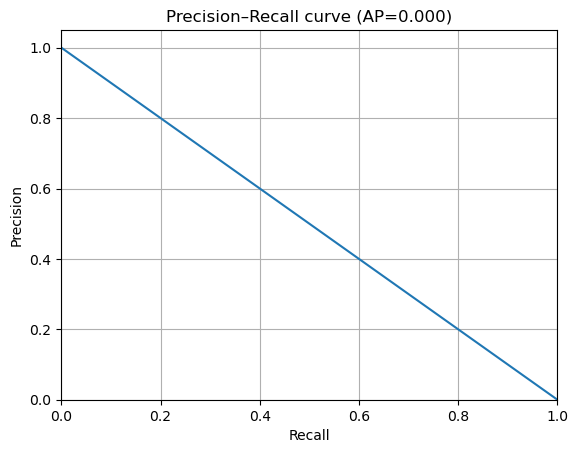

The precision at 0.95 recall is 0.0000


In [42]:
def plot_pr_curve(scores, labels, title="Precision–Recall curve"):
    scores = np.asarray(scores).ravel()
    labels = np.asarray(labels).astype(int).ravel()

    precision, recall, thresholds = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{title} (AP={ap:.3f})")
    plt.ylim(0.0, 1.05)
    plt.xlim(0.0, 1.0)
    plt.grid(True)
    plt.savefig("./figures/PRC_latest.png", dpi=300)
    plt.show()

plot_pr_curve(df['scores'], df['labels'])

def precision_at_threshold(scores, labels, recall):
    threshold = torch.quantile(torch.Tensor(scores[labels == 0].values), 1.0-recall)
    scores = torch.Tensor(scores.values)
    labels = torch.Tensor(labels.values)
    preds = (scores >= threshold).long()  # predicted anomalies

    tp = ((preds == 1) & (labels == 1)).sum().item()
    fp = ((preds == 1) & (labels == 0)).sum().item()

    precision = tp / (tp + fp + 1e-8)
    return precision

target_recall = 0.95
prec = precision_at_threshold(df['scores'], df['labels'], target_recall)
print(f"The precision at {target_recall} recall is {prec:.4f}")

In [11]:
#per k-mer evaluation
base_map = {0: "A", 1: "C", 2: "G", 3: "T"}

def kmer_from_window(x):
    idx = x[:, :4].argmax(dim=1).cpu().numpy()
    return "".join(base_map[int(i)] for i in idx)

def evaluate_per_kmer(model, loader, device="cuda"):
    model.eval()
    loss_dict = defaultdict(list)

    with torch.no_grad():
        for x, lb, pos in loader:
            x = x.to(device)
            out = model(x)
            recon_score = ((out["x_hat"] - x) ** 2).mean(dim=(1, 2))  # [B]

            # Decode k-mer for every datum in the batch
            for i in range(x.size(0)):
                kmer = kmer_from_window(x[i])
                loss_dict[kmer].append(float(recon_score[i].detach().cpu()))

    return loss_dict

# {kmer: [loss]}
un_loss = evaluate_per_kmer(model, test_loader)   
mod_loss= evaluate_per_kmer(model, mod_loader)

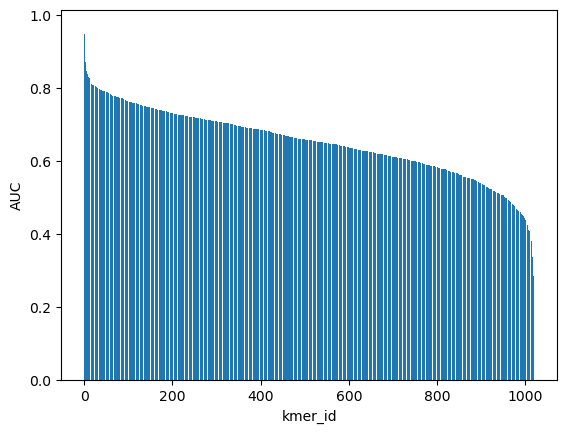

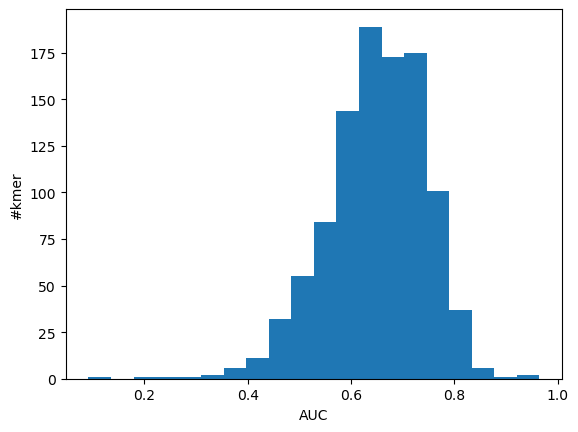

In [12]:
def ROCbykmer(un_loss, mod_loss):
    kmer_stats = []
    
    for km in un_loss.keys():
        un_arr = np.array(un_loss[km])
        mod_arr= np.array(mod_loss.get(km, []))
    
        if len(mod_arr) == 0: #skip kmers absent in mod set
            continue
    
        mean_un = un_arr.mean()
        mean_mod= mod_arr.mean()
    
        # ROC for this k-mer
        labels, scores = labscore(un_arr, mod_arr)
        fpr, tpr, thresholds = roc_curve(labels, scores)
        aucs = auc(fpr, tpr)
        kmer_stats.append((km, len(un_arr), len(mod_arr), mean_un, mean_mod, aucs))

    kmer_stats.sort(key=lambda t: t[-1], reverse=True)
    return pd.DataFrame(kmer_stats, columns=['kmer','#un','#mod','mean_un','mean_mod','auc'])
    
aucs = ROCbykmer(un_loss, mod_loss)

plt.bar(aucs.index, aucs.auc)
plt.xlabel("kmer_id")
plt.ylabel("AUC")
plt.savefig("kmer-bar_CNNtrans_b-3.png", dpi=300)
plt.show()

plt.hist(aucs.auc, bins=20)
plt.xlabel("AUC")
plt.ylabel("#kmer")
plt.savefig("kmer-auc_CNNtrans_b-3.png", dpi=300)
plt.show()

In [43]:
def evaluate_per_read(model, loader, device="cuda"):
    loss_list, label_list, pos_list = [], [], []
    model.eval()

    with torch.no_grad():
        for x, y, pos in loader:                 # batch
            x = x.to(device)
            out = model(x)
            recon_score = ((out["x_hat"] - x) ** 2).mean(dim=(1, 2))

            loss_list.extend(recon_score.detach().cpu().tolist())
            label_list.extend(y.cpu().tolist())
            pos_list.extend(pos.cpu().tolist())

    return loss_list, label_list, pos_list

# aggregate score by position
def aggregate_by_site(losses, labels, positions, agg="mean"):
    score_dict  = defaultdict(list)
    label_dict  = defaultdict(list)

    for s, l, p in zip(losses, labels, positions):
        ps = str(p[2])+'-'+str(p[1])
        score_dict[ps].append(s)
        label_dict[ps].append(l)

    site_score  = []
    site_label  = []

    for p in score_dict:
        vals = np.array(score_dict[p])
        if agg == "median":
            site_score.append(np.median(vals))
        elif agg == "max":
            site_score.append(np.max(vals))
        else:
            site_score.append(np.mean(vals))

        # majority vote for label, or "any-mod" rule
        lab = np.array(label_dict[p])
        site_label.append(int((lab == 1).any()))   # 1 if ≥1 mod read

    return np.array(site_score), np.array(site_label)

loss_r1, lab_r1, pos_r1 = evaluate_per_read(model, val_loader)
loss_r2, lab_r2, pos_r2 = evaluate_per_read(model, mod_loader)
pos_r = [list(t) for t in (set(map(tuple, pos_r1)) & set(map(tuple, pos_r2)))]
score_site1, label_site1 = aggregate_by_site(loss_r1, lab_r1, pos_r, agg="mean")
score_site2, label_site2 = aggregate_by_site(loss_r2, lab_r2, pos_r, agg="mean")
score_site = np.concat([score_site1, score_site2])
label_site = np.concat([label_site1, label_site2])

# ROC at site level
fpr, tpr, thresholds = roc_curve(label_site, score_site)
auc_site = auc(fpr, tpr)

print(f"Site-level ROC-AUC = {auc_site:.3f}  (N_sites = {len(score_site)})")

NameError: name 'test_loader' is not defined

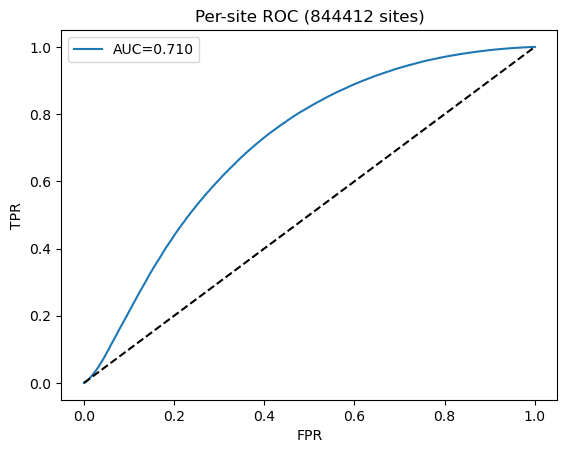

KeyboardInterrupt: 

In [ ]:
plt.plot(fpr, tpr, label=f"AUC={auc_site:.3f}")
plt.plot([0,1],[0,1],'k--'); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title(f"Per-site ROC ({len(score_site)} sites)"); plt.legend()
plt.savefig("site-ROC_CNNtrans_b-3.png", dpi=300)
plt.show()

plt.bar(list(range(len(score_site2))), score_site2, alpha=0.5, label='5mC');
plt.bar(list(range(len(score_site1))), score_site1, alpha=0.5, label='C');
plt.xlabel("Site")
plt.ylabel("Loss")
plt.legend()
plt.savefig("site-bar_CNNtrans_b-3.png", dpi=300)
plt.show()